# Running Tensor-cell2cell on Google Colab with a GPU

## Citations

If you plan using this notebook with your own tensors, please cite these references:

- **Tensor-cell2cell Tool**: Armingol E., Baghdassarian H., Martino C., Perez-Lopez A., Aamodt C., Knight R., Lewis N.E. Context-aware deconvolution of cell-cell communication with Tensor-cell2cell. Nat Commun 13, 3665 (2022). https://doi.org/10.1038/s41467-022-31369-2
- And citations associated with where you got your LR pairs from.




## Initial setups

### Enabling the GPU

**First, you'll need to enable GPUs for the notebook:**

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

### Installing necessary libraries

In [ ]:
!pip install cell2cell

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.1/175.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.0/596.0 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 71.1 MB/s eta 0:00:00


In [ ]:
#!pip install -U pandas # run in case there is an error loading the metadata. Alternatively specify the version of pandas that you used when saving metadata (e.g. pip install -U pandas==1.0.0)

### Loading libraries

In [ ]:
import cell2cell as c2c

import pandas as pd
import numpy as np

In [ ]:
c2c.__version__

'0.8.4'

## Load Data

### Directories

In [ ]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!ls /content/drive/

import os

data_folder = '/content/drive/MyDrive/Colab Notebooks/'
directory = os.fsencode(data_folder)

for file in os.listdir(data_folder):
    print(file)

MyDrive
Copia de TC2C-Example-GoogleColab-PreBuilt-GPU.ipynb
gener2022.ipynb
Tensor.pkl
Tensor-Metadata.pkl
tensor_maria.zip
Elbow.pdf
Loadings.xlsx
Tensor-Factorization.pdf
Tensor_with_results.pkl
Tensor-Factorization.gdoc
Factor5_HBV_network.pdf
Factor5_HC_network.pdf
Factor5_HDV_network.pdf
Copia de TC2C-Example-GoogleColab-GPU.ipynb
TopFactor5_Hep_to_KC.csv
TopFactor5_Hep_to_KC.xlsx
context_boxplot_1200dpi.png
context_factor5_1200dpi.png
context_factor5_1200dpi_colors.png
Clustermap-CC-Pairs.pdf
Clustermap-CC-Pairs.png
grouped_hepatocyte_kc_interaction_counts_stacked_normalized_HC.png
all_factors_KC_heatmaps_topLR.png
context_factor1_1200dpi_colors.png
context_facto3_1200dpi_colors.png
context_facto2_1200dpi_colors.png
context_facto1_1200dpi_colors.png
context_fact4_1200dpi_colors.png
context_fact5_1200dpi_colors.png
Clustermap-CC-Pairs_factor1.png
Clustermap-CC-Pairs_factor2.png
Clustermap-CC-Pairs_factor3.png
Clustermap-CC-Pairs_factor4.png
Clustermap-CC-Pairs_factor5.png
heatmap

### Tensor

Load the tensor

In [ ]:
tensor = c2c.io.read_data.load_tensor(data_folder + '/Tensor_with_results.pkl', backend='pytorch', device='cuda')

In [ ]:
tensor.tensor.shape

torch.Size([18, 4017, 34, 34])

**Dimension Metadata for plotting**

In [ ]:
meta_tensor = c2c.io.read_data.load_variable_with_pickle(data_folder + '/Tensor-Metadata.pkl')



## Tensor-cell2cell Analysis

### Run Tensor-cell2cell

Here we use the ```tf_optimization='regular'```, which is faster but generates less robust results. We recommend using ```tf_optimization='robust```, which takes longer to run.

/usr/local/lib/python3.11/dist-packages/tensorly/backend/pytorch_backend.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(


Running Elbow Analysis


100%|██████████| 10/10 [6:51:26<00:00, 2468.66s/it]


The rank at the elbow is: 5
Running Tensor Factorization


100%|██████████| 100/100 [3:12:03<00:00, 115.23s/it]


Best model has a normalized error of: 0.763
Generating Outputs
Loadings of the tensor factorization were successfully saved into /content/drive/MyDrive/Colab Notebooks//Loadings.xlsx


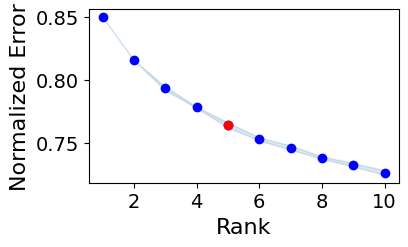

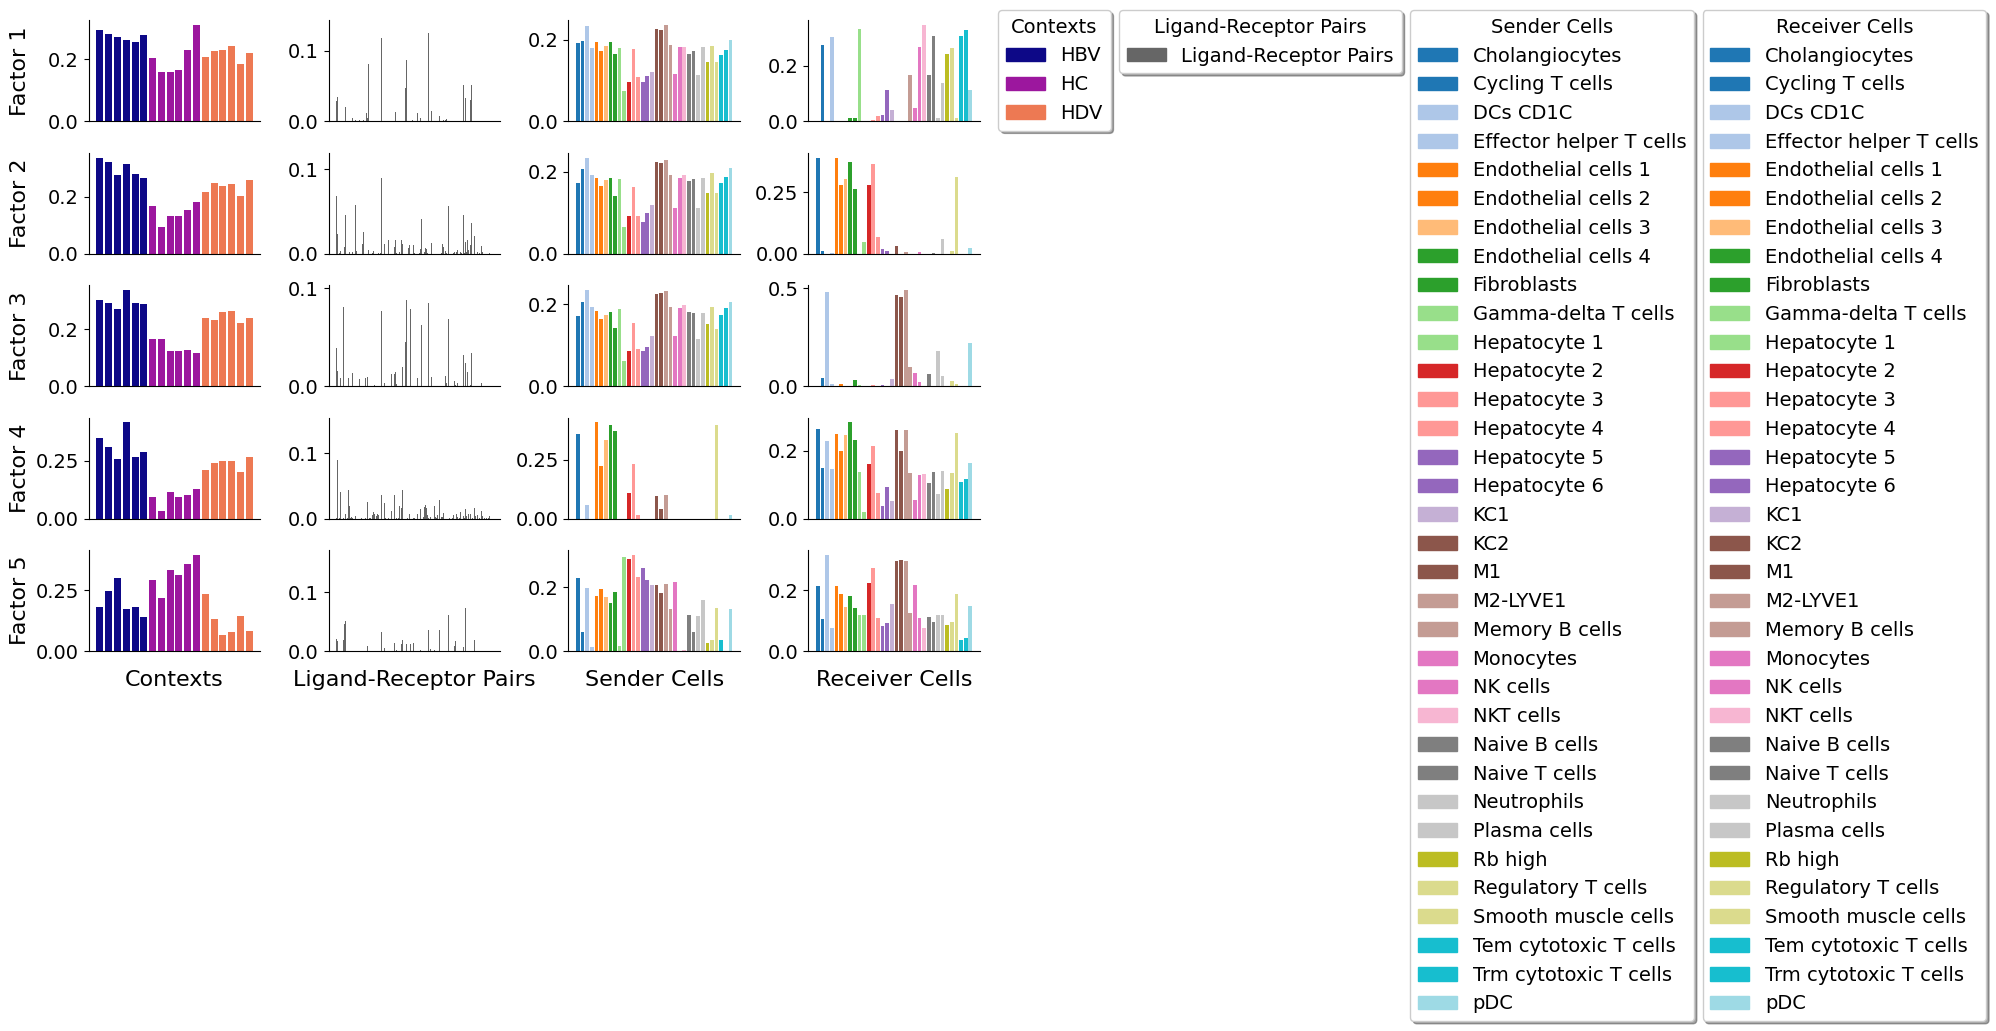

In [ ]:
tensor2 = c2c.analysis.run_tensor_cell2cell_pipeline(tensor,
                                                     meta_tensor,
                                                     copy_tensor=True, # Whether to output a new tensor or modifying the original
                                                     rank=None, # Number of factors to perform the factorization. If None, it is automatically determined by an elbow analysis
                                                     tf_optimization='robust', # To define how robust we want the analysis to be.
                                                     random_state=888, # Random seed for reproducibility
                                                     device='cuda', # Device to use. If using GPU and PyTorch, use 'cuda'. For CPU use 'cpu'
                                                     elbow_metric='error', # Metric to use in the elbow analysis.
                                                     smooth_elbow=False, # Whether smoothing the metric of the elbow analysis.
                                                     upper_rank=10, # Max number of factors to try in the elbow analysis
                                                     tf_init='random', # Initialization method of the tensor factorization
                                                     tf_svd='numpy_svd', # Type of SVD to use if the initialization is 'svd'
                                                     cmaps=None, # Color palettes to use in color each of the dimensions. Must be a list of palettes.
                                                     sample_col='Element', # Columns containing the elements in the tensor metadata
                                                     group_col='Category', # Columns containing the major groups in the tensor metadata
                                                     fig_fontsize=14, # Fontsize of the figures generated
                                                     output_folder=data_folder, # Whether to save the figures and loadings in files. If so, a folder pathname must be passed
                                                     output_fig=True, # Whether to output the figures. If False, figures won't be saved a files if a folder was passed in output_folder.
                                                     fig_format='pdf', # File format of the figures.
                                                    )

**Top genes in each factor**

In [ ]:
for i in range(tensor2.rank):
    print(tensor2.get_top_factor_elements('Ligand-Receptor Pairs', 'Factor {}'.format(i+1), 10))
    print('')

HMGB1^CXCR4       0.136062
MIF^CD44_CD74     0.134877
VIM^CD44          0.134507
MIF^CD74_CXCR4    0.131420
LGALS1^PTPRC      0.125679
PKM^CD44          0.124084
CALM1^PTPRA       0.123150
CD99^CD81         0.121117
LGALS1^CD69       0.119481
TGFB1^CXCR4       0.117856
Name: Factor 1, dtype: float32

CALM1^PTPRA    0.113483
TGFB1^ITGB1    0.111851
ARF1^INSR      0.111214
TGFB1^LPP      0.110743
CALM1^INSR     0.108997
CALM3^INSR     0.108162
HLA-A^APLP2    0.106995
GNAI2^CAV1     0.103878
CD99^CD81      0.103304
CALR^ITGAV     0.101838
Name: Factor 2, dtype: float32

VIM^CD44          0.098066
HLA-C^LILRB2      0.096699
HLA-A^LILRB2      0.096428
HLA-B^LILRB2      0.096020
HLA-C^LILRB1      0.094705
HLA-A^LILRB1      0.094515
HLA-B^LILRB1      0.094226
HMGB1^CXCR4       0.093545
HLA-F^LILRB2      0.092686
MIF^CD74_CXCR4    0.091598
Name: Factor 3, dtype: float32

LAMB2^RPSA     0.147777
NID1^ITGB1     0.133265
HSPG2^ITGB1    0.130354
COL4A1^CD47    0.130084
MDK^NCL        0.121515
JAG1

In [ ]:
# Export Tensor after decomposition

c2c.io.export_variable_with_pickle(tensor, data_folder + 'Tensor_with_results.pkl')

In [ ]:
factors = tensor.factors

In [ ]:
factors.keys()


odict_keys(['Contexts', 'Ligand-Receptor Pairs', 'Sender Cells', 'Receiver Cells'])

In [ ]:
print(tensor.factors.keys())


odict_keys(['Contexts', 'Ligand-Receptor Pairs', 'Sender Cells', 'Receiver Cells'])


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Element': ['CHB8', 'CHB3', 'FC6', 'CHB7', 'CHB9', 'CHB2', '52', '51', '50', '49', '46', '48',
                'L933', 'L917', 'L902', 'L896', 'L758', 'L743'],
    'Category': ['HBV', 'HBV', 'HBV', 'HBV', 'HBV', 'HBV',
                 'HC', 'HC', 'HC', 'HC', 'HC', 'HC',
                 'HDV', 'HDV', 'HDV', 'HDV', 'HDV', 'HDV']
})



In [ ]:
metadict = dict(zip(df['Element'], df['Category']))


/usr/local/lib/python3.12/dist-packages/cell2cell/plotting/factor_plot.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=x,
/usr/local/lib/python3.12/dist-packages/cell2cell/plotting/factor_plot.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/usr/local/lib/python3.12/dist-packages/cell2cell/plotting/factor_plot.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=x,
/usr/local/lib/python3.12/dist-packages/cell2cell/plotting/factor_plot.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

(<Figure size 1200x600 with 6 Axes>,
 array([[<Axes: title={'center': 'Factor 1'}, ylabel='Context Loadings'>,
         <Axes: title={'center': 'Factor 2'}, ylabel=' '>,
         <Axes: title={'center': 'Factor 3'}, ylabel=' '>],
        [<Axes: title={'center': 'Factor 4'}, ylabel='Context Loadings'>,
         <Axes: title={'center': 'Factor 5'}, ylabel=' '>, <Axes: >]],
       dtype=object))

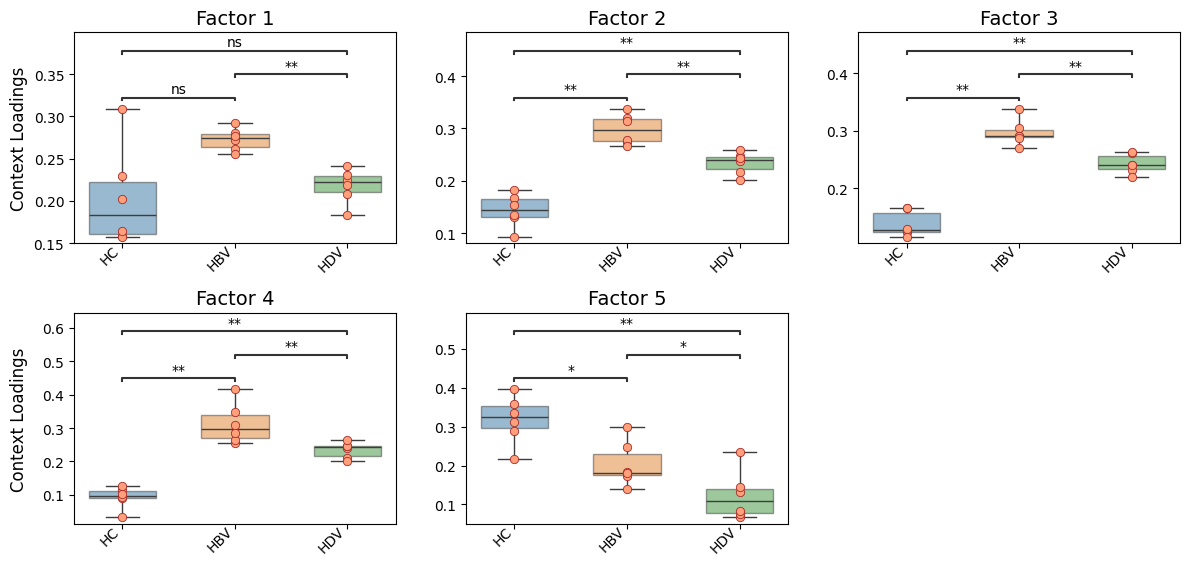

In [ ]:
group_order = ['HC', 'HBV', 'HDV']

c2c.plotting.factor_plot.context_boxplot(
    context_loadings=tensor.factors['Contexts'],
    metadict=metadict,
    group_order=group_order,
    nrows=2,
    figsize=(12, 6)
)


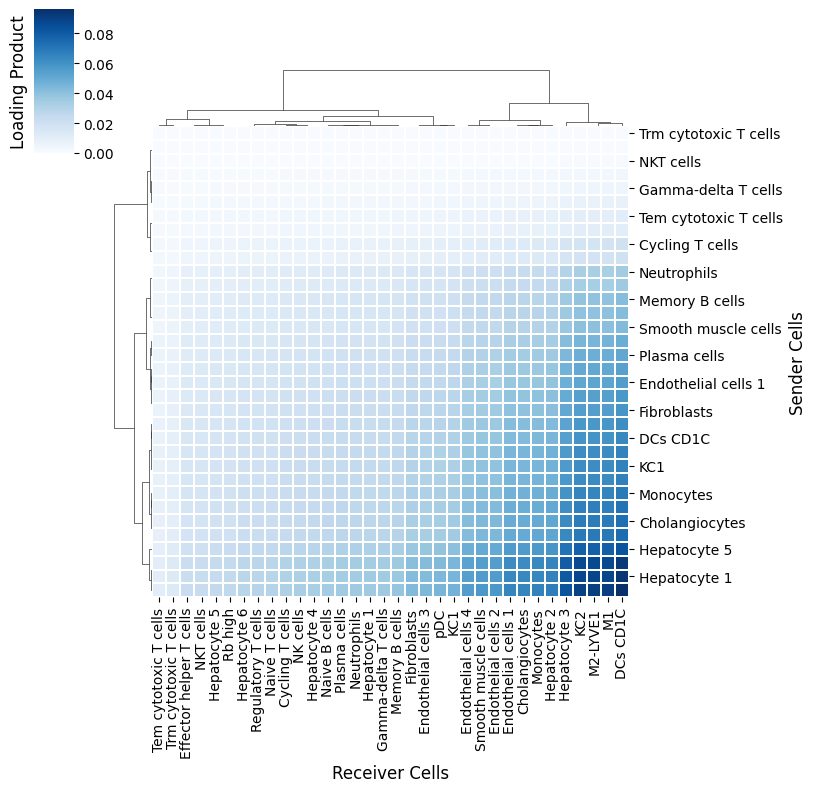

In [ ]:
selected_factor = 'Factor 5'

loading_product = c2c.analysis.tensor_downstream.get_joint_loadings(tensor.factors,
                                                                    dim1='Sender Cells',
                                                                    dim2='Receiver Cells',
                                                                    factor=selected_factor,
                                                                   )

lprod_cm = c2c.plotting.loading_clustermap(loading_product.T, # Remove .T to transpose the axes
                                           use_zscore=False, # Whether standardizing the loadings across factors
                                           figsize=(8, 8),
                                           filename='Clustermap-CC-Pairs.pdf',
                                           cbar_label='Loading Product',
                                          )

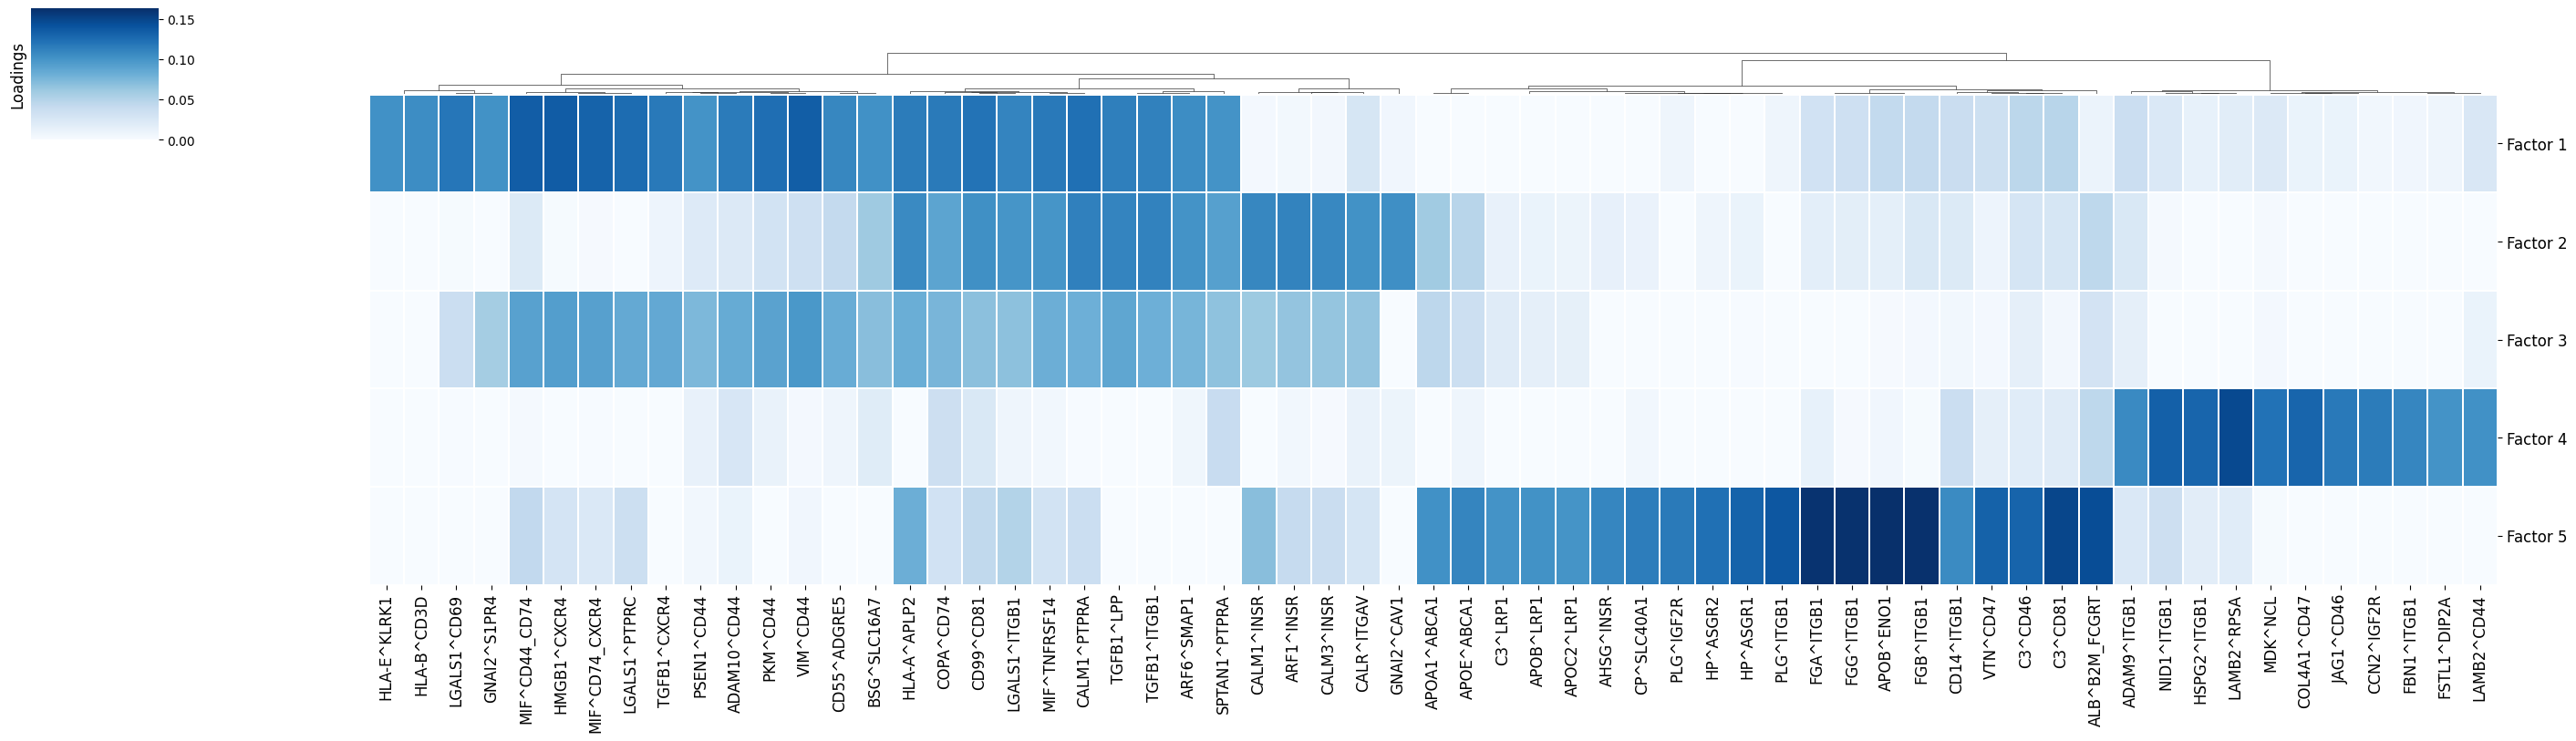

In [ ]:
c2c.plotting.loading_clustermap(loadings=tensor.factors['Ligand-Receptor Pairs'],
                                    loading_threshold=0.1,
                                    use_zscore=False,
                                    figsize=(28, 8),
                                    filename="heatmap",
                                    row_cluster=False,
                                    tick_fontsize=12,
                                    dendrogram_ratio=0.15,
                                   )



In [ ]:
c2c.io.export_variable_with_pickle(tensor, "Tensor_with_results.pk.pkl")